<a href="https://colab.research.google.com/github/faheema2006/MLOPS/blob/main/SkillSync(Linear_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving clean_resume_dataset.csv to clean_resume_dataset.csv


Index(['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary',
       'Skills', 'Experience', 'Education', 'Text', 'Source'],
      dtype='object')
Predicted Values:
[40.26853233 17.20897242 12.63163769 12.06302367 16.01948476 19.1843081
 19.72365137 17.87910088 17.89818025  7.7671315 ]
Actual Values:
[35 17 15  5 25 13 20 20 10  8]


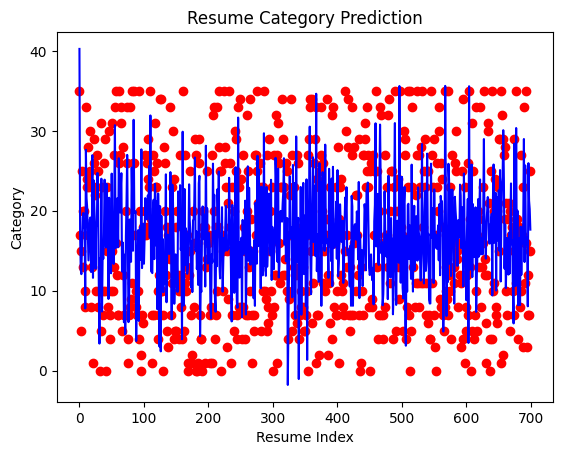

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('/content/clean_resume_dataset.csv')

print(dataset.columns)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)

X = tfidf.fit_transform(dataset['Text']).toarray()

dataset['Category'] = dataset['Category'].astype('category').cat.codes

y = dataset.iloc[:, 1].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

print("Actual Values:")
print(y_test[:10])

plt.scatter(range(len(y_test)), y_test, color='red')

plt.plot(range(len(y_pred)), y_pred, color='blue')

plt.title('Resume Category Prediction')

plt.xlabel('Resume Index')

plt.ylabel('Category')

plt.show()